# Downstream Processing Unit Operations

This notebook demonstrates downstream processing operations for biomanufacturing:
- **Centrifuge**: Cell separation using Sigma factor theory
- **Ultrafiltration/Diafiltration**: Protein concentration and buffer exchange
- **Chromatography**: Protein A capture for mAb purification

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'   # Must be BEFORE import jax

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow_bio import (
    # Centrifuge
    Centrifuge, CentrifugeParams,
    DiscStackCentrifuge, DiscStackParams,
    stokes_velocity, g_force,
    # Filtration
    Ultrafiltration, UltrafiltrationParams,
    Diafiltration, DiafiltrationParams,
    TFF, diavolumes_required,
    # Chromatography
    ProteinAChromatography, ProteinAParams,
    langmuir_isotherm,
)
from difflow import make_stream, get_flows

## 1. Centrifuge for Cell Separation

Centrifuges separate cells from culture broth using centrifugal force. The key parameter is the **Sigma factor (Sigma)**, which represents the equivalent settling area.

$Q_{crit} = 2 v_s \Sigma$

where $v_s$ is the Stokes settling velocity.

In [2]:
# Calculate Stokes velocity for typical cells
v_s = stokes_velocity(
    d=5e-6,        # 5 um diameter
    rho_p=1050.0,  # Cell density kg/m^3
    rho_f=1000.0,  # Broth density kg/m^3
    mu=0.001,      # Viscosity Pa.s
)
print(f"Stokes settling velocity: {float(v_s)*1e6:.3f} um/s")

# Calculate g-force for typical centrifuge
rcf = g_force(r=0.1, rpm=6000)
print(f"Relative Centrifugal Force: {float(rcf):.0f} g")

Metal device set to: Apple M4 Pro
Stokes settling velocity: 0.681 um/s
Relative Centrifugal Force: 4024 g


W0000 00:00:1765400745.187774 7007916 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765400745.196556 7007916 service.cc:145] XLA service 0x60000167d100 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765400745.196566 7007916 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765400745.197641 7007916 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765400745.197649 7007916 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


In [3]:
# Create a disc-stack centrifuge
disc_params = DiscStackParams(
    n_discs=80,
    r_outer=0.12,    # 12 cm
    r_inner=0.04,    # 4 cm
    half_angle=0.698, # 40 degrees
    rpm=7000,
    efficiency=0.75,
)

centrifuge = DiscStackCentrifuge(disc_params)
print(f"Sigma factor: {float(centrifuge.sigma):.1f} m^2")

# Simulate cell separation from harvest
harvest = make_stream(
    {"cells": 50.0, "mAb": 5.0, "HCP": 10.0, "DNA": 0.5},
    T=310.0, P=101325.0
)

(concentrate, clarified), info = centrifuge(
    harvest,
    Q=1e-4,  # 0.1 L/s = 360 L/h
    concentrate_fraction=0.05,  # 5% to cell paste
)

print(f"\nSeparation Results:")
print(f"  Cell recovery: {float(info['cell_recovery'])*100:.1f}%")
print(f"  Critical diameter: {float(info['critical_diameter'])*1e6:.2f} um")

conc_flows = get_flows(concentrate)
clar_flows = get_flows(clarified)
print(f"\nClarified broth:")
print(f"  Cells: {float(clar_flows['cells']):.2f} (from 50)")
print(f"  mAb: {float(clar_flows['mAb']):.2f} (from 5)")

Sigma factor: 18204.9 m^2

Separation Results:
  Cell recovery: 75.0%
  Critical diameter: 0.18 um

Clarified broth:
  Cells: 12.50 (from 50)
  mAb: 4.75 (from 5)


## 2. Ultrafiltration and Diafiltration

UF/DF is used to:
1. **Concentrate** proteins by removing water and small molecules
2. **Exchange buffer** through diafiltration

In [4]:
# Define UF membrane with species rejections
uf_params = UltrafiltrationParams(
    membrane_area=2.0,  # m^2
    MWCO=30.0,          # 30 kDa
    rejection={
        "mAb": 0.999,     # ~150 kDa, fully retained
        "HCP": 0.5,       # Mix of sizes
        "buffer_salt": 0.0,  # Small, fully permeable
    },
    Lp=50.0,  # L/m^2/h/bar
)

uf = Ultrafiltration(uf_params)

# Concentrate the clarified harvest
uf_feed = make_stream(
    {"mAb": 5.0, "HCP": 2.0, "buffer_salt": 50.0},
    T=300.0, P=101325.0
)

(retentate, permeate), info = uf(uf_feed, concentration_factor=10.0)

print("Ultrafiltration (10x concentration):")
ret_flows = get_flows(retentate)
for species in ret_flows:
    original = float(get_flows(uf_feed)[species])
    final = float(ret_flows[species])
    print(f"  {species}: {original:.2f} -> {final:.2f} (recovery: {final/original*100:.1f}%)")

Ultrafiltration (10x concentration):
  mAb: 5.00 -> 5.00 (recovery: 99.9%)
  HCP: 2.00 -> 1.10 (recovery: 55.0%)
  buffer_salt: 50.00 -> 5.00 (recovery: 10.0%)


In [5]:
# Diafiltration for buffer exchange
df_params = DiafiltrationParams(
    membrane_area=2.0,
    rejection={"mAb": 0.999, "old_buffer": 0.0, "new_buffer": 0.0},
)

df = Diafiltration(df_params)

# Start with concentrated protein in old buffer
df_feed = make_stream(
    {"mAb": 50.0, "old_buffer": 100.0},
    T=300.0, P=101325.0
)

new_buffer = make_stream(
    {"new_buffer": 100.0},
    T=300.0, P=101325.0
)

# Calculate diavolumes needed for 99% exchange
n_dv_needed = diavolumes_required(
    initial_conc=jnp.array(100.0),
    target_conc=jnp.array(1.0),  # 99% reduction
    rejection=jnp.array(0.0),
)
print(f"Diavolumes needed for 99% buffer exchange: {float(n_dv_needed):.1f}")

# Perform diafiltration
(ret_df, perm_df), info_df = df(df_feed, new_buffer, n_diavolumes=5.0)

print(f"\nDiafiltration Results (5 diavolumes):")
ret_df_flows = get_flows(ret_df)
print(f"  mAb retained: {float(ret_df_flows['mAb']):.1f} (of 50)")
print(f"  Old buffer remaining: {float(ret_df_flows['old_buffer']):.2f} (of 100)")
print(f"  New buffer added: {float(ret_df_flows['new_buffer']):.1f}")
print(f"  Exchange efficiency: {float(info_df['exchange_efficiency']['old_buffer'])*100:.1f}%")

Diavolumes needed for 99% buffer exchange: 4.6

Diafiltration Results (5 diavolumes):
  mAb retained: 49.8 (of 50)
  Old buffer remaining: 0.67 (of 100)
  New buffer added: 744.9
  Exchange efficiency: 99.3%


## 3. Protein A Chromatography

Protein A is the workhorse for mAb purification, providing high selectivity for IgG antibodies.

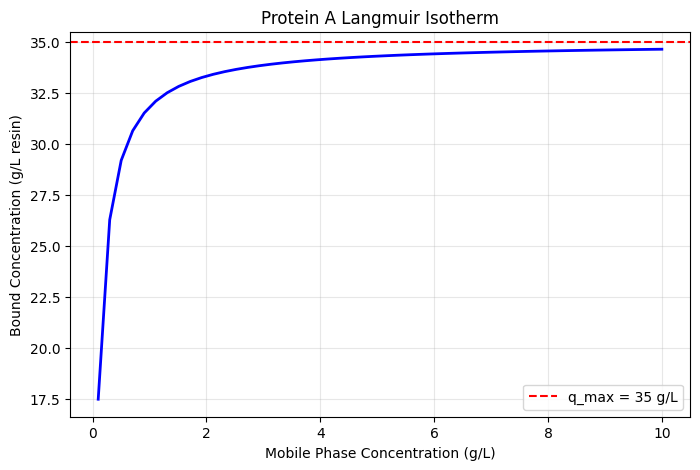

In [6]:
# Langmuir isotherm for Protein A binding
C_range = jnp.linspace(0.1, 10, 50)
q_values = [float(langmuir_isotherm(C, q_max=jnp.array(35.0), K_d=jnp.array(0.1))) for C in C_range]

plt.figure(figsize=(8, 5))
plt.plot(C_range, q_values, 'b-', linewidth=2)
plt.axhline(y=35, color='r', linestyle='--', label='q_max = 35 g/L')
plt.xlabel('Mobile Phase Concentration (g/L)')
plt.ylabel('Bound Concentration (g/L resin)')
plt.title('Protein A Langmuir Isotherm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Protein A column parameters
proa_params = ProteinAParams(
    column_volume=1.0,    # 1 L column
    q_max=35.0,           # 35 g/L static capacity
    K_d=0.1,              # High affinity
    target_species="mAb",
    yield_factor=0.95,    # 95% elution recovery
    impurity_clearance={
        "HCP": 2.0,       # 2 log reduction
        "DNA": 3.0,       # 3 log reduction
        "cells": 4.0,     # 4 log reduction
    },
)

proa = ProteinAChromatography(proa_params)

# Clarified and concentrated harvest
proa_feed = make_stream(
    {"mAb": 50.0, "HCP": 5.0, "DNA": 0.1},
    T=300.0, P=101325.0
)

# Calculate recommended load volume
load_vol = proa.calculate_load_volume(
    feed_concentration=5.0,  # 5 g/L mAb
    target_utilization=0.8,
)
print(f"Recommended load volume: {float(load_vol):.1f} L")

# Run chromatography
(product, waste), info = proa(proa_feed, load_volume=10.0)

print(f"\nProtein A Chromatography Results:")
print(f"  Yield: {float(info['yield'])*100:.1f}%")
print(f"  Purity: {float(info['purity'])*100:.1f}%")
print(f"  Capacity utilization: {float(info['capacity_utilization'])*100:.1f}%")

prod_flows = get_flows(product)
print(f"\nProduct pool composition:")
for species, flow in prod_flows.items():
    print(f"  {species}: {float(flow):.4f}")

Recommended load volume: 5.0 L

Protein A Chromatography Results:
  Yield: 95.0%
  Purity: 99.9%
  Capacity utilization: 26.2%

Product pool composition:
  mAb: 8.6207
  HCP: 0.0091
  DNA: 0.0000


### Differentiable Optimization

We can optimize the load volume to maximize productivity.

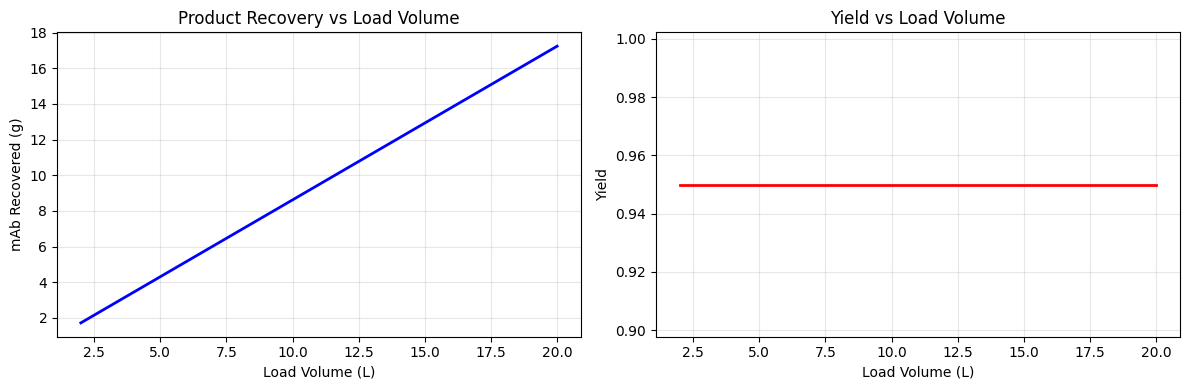


Gradient of productivity at load_vol=10L: 0.8621


In [8]:
def column_productivity(load_volume):
    """Compute mAb mass recovered per cycle."""
    (product, _), info = proa(proa_feed, load_volume=load_volume)
    return product["F_mAb"]

# Scan load volumes
load_vols = jnp.linspace(2, 20, 20)
productivities = [float(column_productivity(lv)) for lv in load_vols]
yields = []
for lv in load_vols:
    (_, _), info = proa(proa_feed, load_volume=float(lv))
    yields.append(float(info['yield']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(load_vols, productivities, 'b-', linewidth=2)
ax1.set_xlabel('Load Volume (L)')
ax1.set_ylabel('mAb Recovered (g)')
ax1.set_title('Product Recovery vs Load Volume')
ax1.grid(True, alpha=0.3)

ax2.plot(load_vols, yields, 'r-', linewidth=2)
ax2.set_xlabel('Load Volume (L)')
ax2.set_ylabel('Yield')
ax2.set_title('Yield vs Load Volume')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gradient at a specific point
grad_fn = jax.grad(column_productivity)
grad_at_10 = grad_fn(jnp.array(10.0))
print(f"\nGradient of productivity at load_vol=10L: {float(grad_at_10):.4f}")

## 4. Summary

Downstream processing operations in difflow_bio:

| Operation | Key Parameters | Use Case |
|-----------|---------------|----------|
| Centrifuge | Sigma factor, efficiency | Cell removal |
| Ultrafiltration | Rejection, CF | Protein concentration |
| Diafiltration | Diavolumes | Buffer exchange |
| Protein A | Capacity, yield, clearance | mAb capture |

All operations are fully differentiable for gradient-based optimization!